# Sutton & Barto Chapter 2

This notebook mirrors the classic stationary 10-armed testbed from Sutton & Barto (Reinforcement Learning: An Introduction, Chapter 2). We build Gaussian bandits and compare epsilon-greedy variants.

## Setup: 10-armed Gaussian bandit

Each arm has a true mean drawn from $\mathcal{N}(0,1)$ and unit standard deviation.

In [3]:
import numpy as np
from banditry import Bandit, GaussianArm, EpsilonGreedyPolicy

In [4]:
def make_gaussian_testbed(k=10, seed=0):
    rng = np.random.default_rng(seed)
    true_means = rng.normal(loc=0.0, scale=1.0, size=k)
    arms = [GaussianArm(mean=mu, std=1.0) for mu in true_means]
    bandit = Bandit(arms, seed=seed)
    best_idx = int(np.argmax(true_means))
    return bandit, true_means, best_idx

## Epsilon-greedy policies

We compare epsilon-greedy with different parameter values ($\epsilon=0$, $\epsilon=0.01$, and $\epsilon=0.1$). For each, we average reward and % optimal action over many runs.

In [7]:
def simulate(epsilons=(0.0, 0.01, 0.1), runs=500, steps=500):
    avg_rewards = {e: np.zeros(steps) for e in epsilons}
    optimal_action_pct = {e: np.zeros(steps) for e in epsilons}

    for e in epsilons:
        for run in range(runs):
            bandit, _, best = make_gaussian_testbed(seed=run)
            policy = EpsilonGreedyPolicy(bandit, epsilon=e)
            actions, rewards = policy.learn(steps)
            avg_rewards[e] += rewards
            optimal_action_pct[e] += (np.array(actions) == best)

        avg_rewards[e] /= runs
        optimal_action_pct[e] = (optimal_action_pct[e] / runs) * 100.0

    return avg_rewards, optimal_action_pct

## Run and plot

Matplotlib will show average reward and % optimal action.

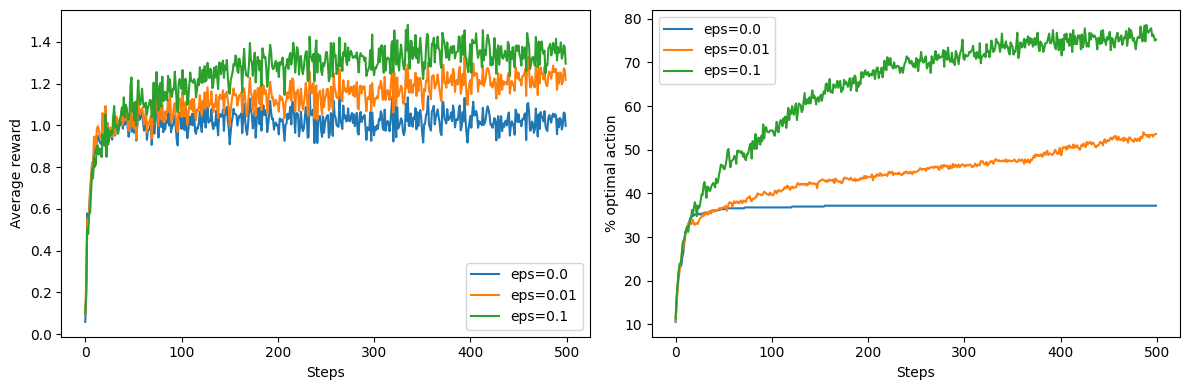

In [8]:
import matplotlib.pyplot as plt

avg_rewards, opt_pct = simulate()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for e, rewards in avg_rewards.items():
    axes[0].plot(rewards, label=f"eps={e}")
axes[0].set_xlabel("Steps")
axes[0].set_ylabel("Average reward")
axes[0].legend()

for e, pct in opt_pct.items():
    axes[1].plot(pct, label=f"eps={e}")
axes[1].set_xlabel("Steps")
axes[1].set_ylabel("% optimal action")
axes[1].legend()

plt.tight_layout()
plt.show()